In [149]:
import mne
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

In [160]:
all_epoch_paths = list(Path("epochs").glob("*.fif"))

## Temporal grid decoder power analysis

In [196]:
response_window = [0.05, 0.3]
# Retain average HG over these many steps within response window
interp_steps = 10
baseline = True

n_bootstrap = 50

all_bootstrap_results = []

In [197]:
def prepare_dataset(metadata, data: np.ndarray, interp_steps=10):
    # Resample over time window.
    n_samples = data.shape[2]
    interp_samples = np.linspace(0, n_samples - 1, interp_steps).astype(int)

    interp_data = np.concatenate([data[:, :, sample_start:sample_end + 1].mean(axis=2)[:, :, np.newaxis]
                                  for sample_start, sample_end in zip(interp_samples[:-1], interp_samples[1:])], axis=2)
    
    # Flatten
    interp_data = interp_data.reshape(interp_data.shape[0], -1)

    return metadata, interp_data

In [198]:
all_epoch_paths

[PosixPath('epochs/EC279_epochs.fif'),
 PosixPath('epochs/EC243_epochs.fif'),
 PosixPath('epochs/EC260_epochs.fif'),
 PosixPath('epochs/EC250_epochs.fif'),
 PosixPath('epochs/EC270_epochs.fif'),
 PosixPath('epochs/EC282_epochs.fif'),
 PosixPath('epochs/EC278_epochs.fif'),
 PosixPath('epochs/EC253_epochs.fif'),
 PosixPath('epochs/EC248_epochs.fif')]

In [200]:
for path in tqdm(all_epoch_paths):
    # DEV: looks like EC282 is missing data?
    if "EC282" in path.stem:
        continue

    subject = path.stem
    epochs = mne.read_epochs(path, preload=True).pick(["ecog"])
    metadata = epochs.metadata

    # Prepare map from behavioral index / selection number to index in epoch ndarray.
    # This is the inverse of epochs.selection
    selection_to_index = {selection: index for index, selection in enumerate(epochs.selection)}

    keep_metadata = metadata[metadata.resampled.isin((metadata.resampled.min(), metadata.resampled.max()))]
    resampled_max = keep_metadata.resampled.max()
    keep_metadata["resampled_right"] = keep_metadata.resampled == resampled_max

    data = epochs.copy()
    if baseline and data.baseline is None:
        data = data.apply_baseline((None, 0))
    data = data.crop(*response_window)

    bootstrap_results = []

    for stim_number, stim_df in tqdm(keep_metadata.groupby("stim_number"), leave=False):
        sample_sizes = (2 ** np.arange(2, np.log(len(stim_df)) / np.log(2))).astype(int)
        for sample_size in sample_sizes:
            for _ in range(n_bootstrap):
                # ensure balanced sample
                n_left = sample_size // 2
                n_right = sample_size - n_left
                sample_metadata = pd.concat([stim_df[~stim_df.resampled_right].sample(n_left),
                                             stim_df[stim_df.resampled_right].sample(n_right)])
                sample_epochs = data._data[[selection_to_index[selection] for selection in sample_metadata.index]]

                # Prepare test dataset (complement of previous)
                test_indices = np.setdiff1d(stim_df.index, sample_metadata.index)
                test_metadata = stim_df.loc[test_indices]
                test_epochs = data._data[[selection_to_index[selection] for selection in test_metadata.index]]

                # Learn and evaluate logistic regression
                sample_metadata, sample_epochs = prepare_dataset(sample_metadata, sample_epochs)
                test_metadata, test_epochs = prepare_dataset(test_metadata, test_epochs)

                if sample_size > 4:
                    cv = StratifiedShuffleSplit(n_splits=4, test_size=0.2)
                    clf = LogisticRegressionCV(cv=cv, max_iter=1000)
                else:
                    clf = LogisticRegression(max_iter=1000)
                clf.fit(sample_epochs, sample_metadata.resampled_right)

                test_predictions = clf.predict(test_epochs)
                test_accuracy = np.mean(test_predictions == test_metadata.resampled_right)

                bootstrap_results.append({"sample_size": sample_size,
                                        "subject": subject,
                                        "stim_number": stim_number,
                                        "train_accuracy": clf.score(sample_epochs, sample_metadata.resampled_right),
                                        "train_auc": roc_auc_score(sample_metadata.resampled_right, clf.predict(sample_epochs)),
                                        "test_accuracy": test_accuracy,
                                        "test_auc": roc_auc_score(test_metadata.resampled_right, test_predictions),
                                        "C": clf.C_[0] if isinstance(clf, LogisticRegressionCV) else np.nan,})
                
    bootstrap_results_df = pd.DataFrame(bootstrap_results)
    bootstrap_results_df = pd.merge(bootstrap_results_df, metadata, how="left", on="stim_number")
    all_bootstrap_results.append(bootstrap_results_df)

  0%|          | 0/9 [00:00<?, ?it/s]

Reading /Users/jon/Downloads/barakeet/epochs/EC279_epochs.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available


/var/folders/6c/4ff4nnfx5417_p6nsqlg4phm0000gn/T/ipykernel_68490/1354669989.py:7: RuntimeWarning: This filename (epochs/EC279_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True).pick(["ecog"])


Adding metadata with 72 columns
862 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


/var/folders/6c/4ff4nnfx5417_p6nsqlg4phm0000gn/T/ipykernel_68490/1354669989.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  keep_metadata["resampled_right"] = keep_metadata.resampled == resampled_max


...

Reading /Users/jon/Downloads/barakeet/epochs/EC248_epochs.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available


/var/folders/6c/4ff4nnfx5417_p6nsqlg4phm0000gn/T/ipykernel_68490/1354669989.py:7: RuntimeWarning: This filename (epochs/EC248_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True).pick(["ecog"])


Adding metadata with 71 columns
864 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


/var/folders/6c/4ff4nnfx5417_p6nsqlg4phm0000gn/T/ipykernel_68490/1354669989.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  keep_metadata["resampled_right"] = keep_metadata.resampled == resampled_max


  0%|          | 0/3 [00:00<?, ?it/s]

In [152]:
# power_analysis_df = pd.merge(power_analysis_data[keep_metadata.index].to_data_frame(long_format=True), power_analysis_metadata,
#                              how="inner", left_on="epoch", right_index=True)
# power_analysis_df

In [153]:
# # sns.lineplot(data=power_analysis_df[power_analysis_df.channel.str.startswith("TemporalGrid")],
# #              x="time", y="value", hue="resampled_right")

# g = sns.FacetGrid(data=power_analysis_df[power_analysis_df.channel.str.startswith("TemporalGrid")],
#                   col="phoneme_pair", hue="resampled_right")
# g.map(sns.lineplot, "time", "value")

In [154]:
# sns.barplot(data=power_analysis_df[power_analysis_df.channel.str.startswith("TemporalGrid")], x="phoneme_pair", y="value", hue="resampled_right")

In [202]:
all_bootstrap_results_df = pd.concat(all_bootstrap_results)
all_bootstrap_results_df.to_csv("bootstrap_results.csv", index=False)

<Axes: xlabel='sample_size', ylabel='test_accuracy'>

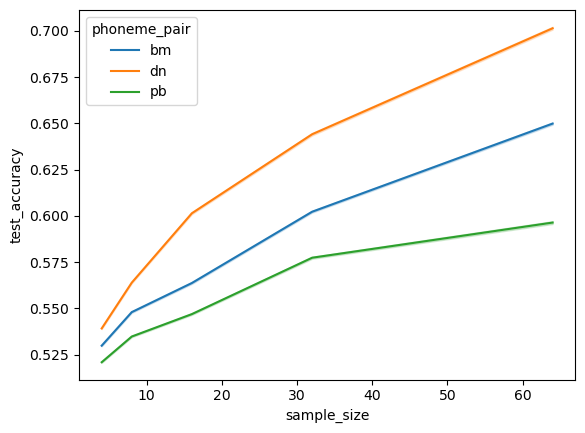

In [203]:
sns.lineplot(data=all_bootstrap_results_df, x="sample_size", y="test_accuracy", hue="phoneme_pair")

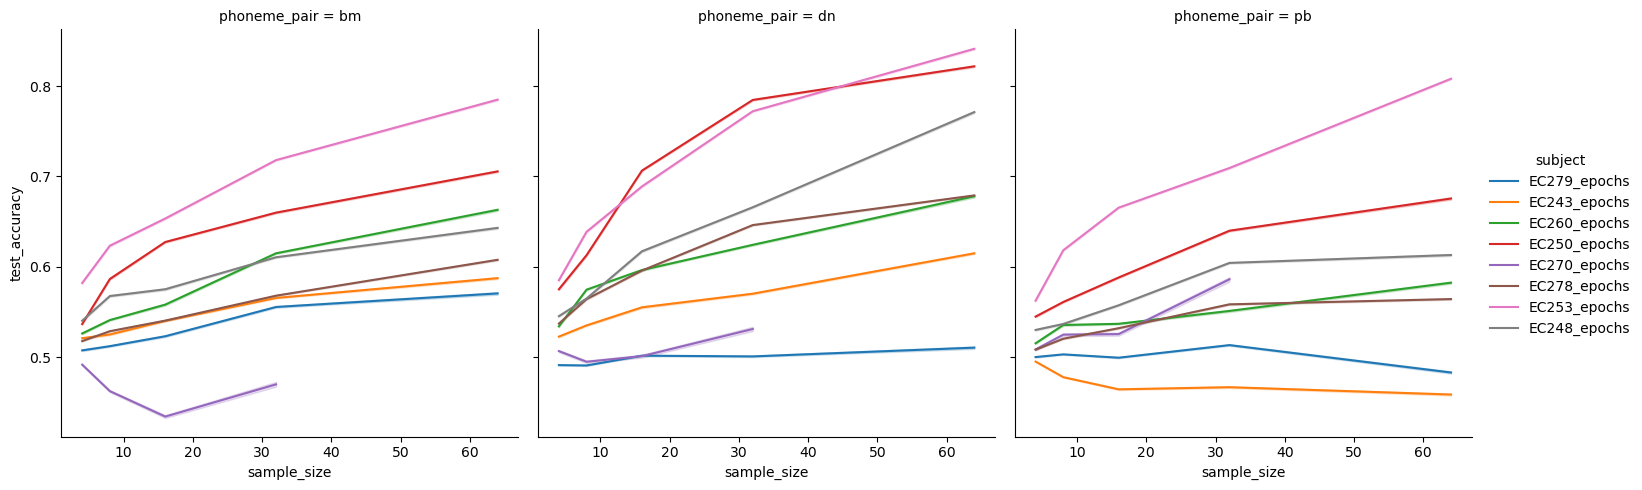

In [206]:
g = sns.FacetGrid(data=all_bootstrap_results_df, col="phoneme_pair", hue="subject", height=5)
g.map(sns.lineplot, "sample_size", "test_accuracy")
g.add_legend()

In [143]:
coef_df = pd.DataFrame(clf.coef_.reshape((-1, 9)))
coef_df.index = power_analysis_data.info.ch_names
coef_df

,0,1,2,3,4,5,6,7,8
FrontalGrid1,-0.000198,-0.000148,0.000216,0.000267,-0.000027,-0.000161,-0.000212,-0.000408,-0.000277
FrontalGrid2,-0.000848,-0.000738,-0.000622,-0.000560,-0.000552,-0.000619,-0.000556,-0.000531,-0.000550
FrontalGrid3,-0.000130,-0.000392,-0.000358,-0.000240,-0.000106,-0.000166,-0.000250,-0.000347,-0.000296
FrontalGrid4,-0.000358,-0.000253,-0.000207,-0.000296,-0.000285,-0.000443,-0.000560,-0.000368,-0.000102
FrontalGrid5,-0.000313,-0.000543,-0.000572,-0.000608,-0.000604,-0.000421,-0.000352,-0.000262,-0.000305
...,...,...,...,...,...,...,...,...,...
TemporalGrid125,-0.000132,-0.000035,-0.000121,-0.000424,-0.000496,-0.000625,-0.000749,-0.000633,-0.000508
TemporalGrid126,-0.000021,0.000028,0.000009,0.000121,0.000614,0.000671,0.000080,-0.000488,-0.000468
TemporalGrid127,-0.000138,-0.000165,-0.000525,-0.000627,-0.000228,0.000194,0.000393,0.000586,0.000367
TemporalGrid128,-0.000981,-0.001008,-0.001034,-0.000978,-0.000502,-0.000006,0.000117,0.000060,-0.000114


In [148]:
coef_df.abs().max(axis=1).sort_values(ascending=False)

TemporalGrid96     0.001735
FrontalGrid77      0.001419
TemporalGrid100    0.001375
FrontalGrid49      0.001253
TemporalGrid24     0.001206
                     ...   
TemporalGrid69     0.000219
FrontalGrid89      0.000203
TemporalGrid15     0.000188
TemporalGrid88     0.000187
stim               0.000019
Length: 257, dtype: float64

<Axes: >

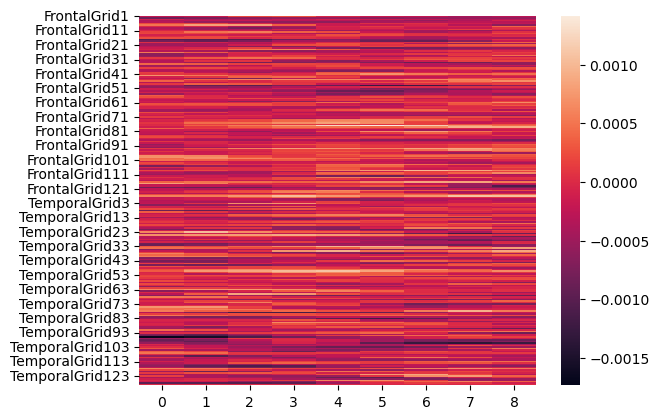

In [144]:
sns.heatmap(coef_df)